# LAB-2: Project Air Quality - Modelling

Please check the answers from the previous lab session. You may need to change the file path of the dataset again. In this lab, we will continue with the same data. But now, we will learn the modeling part of the regression problem.

### General Announcements

* The exercises on this sheet are graded by a maximum of **12 points**. You will be asked to implement several functions.
* Team work is not allowed! Everybody implements his/her own code. Discussing issues with others is fine, sharing code with others is not. 
* If you use any code fragments found on the Internet, make sure you reference them properly.
* You can send your questions via email to the TAs until the deadline.

### <u>Grading:<u>

[6) Baseline Linear Regression](#LR)  (4 points)

[7) Feature Engineering and testing model](#FE)  (2 points)

[8) Decision Tree Regression ](#DT) (1 point)

[9) Random Forest Regression](#RF) (1 point)

[9.1) Blox plot](#bxplot) (2 points)
    
[10) Support Vector Machine](#SVM) (2 point)

In [5]:
# Importing the Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.pylab import rcParams
import seaborn as sns
rcParams['figure.figsize'] = 10, 8

#### 1) Load data<a name="load_data"></a>


- Use `pandas.read_csv('path/to/dataset.csv',header=None,skiprows=1,names=col,na_filter=True, na_values=-200,usecols=use)` to load the data. (0.25 points)

In [6]:
# Defining header
col=['DATE','TIME','CO_GT','PT08_S1_CO','NMHC_GT','C6H6_GT','PT08_S2_NMHC',
     'NOX_GT','PT08_S3_NOX','NO2_GT','PT08_S4_NO2','PT08_S5_O3','T','RH','AH']

# Defining number of columns from csv
use = list(np.arange(len(col)))

# Reading the data from csv
df_air = pd.read_csv(
    'Datasets/AirQualityUCI.csv',  # Write the path of the Air Quality Dataset
    header=None, skiprows=1, names=col, na_filter=True, na_values=-200, usecols=use
)

- Visualize the first and the last 7 rows of the data. (0.25 points)

In [7]:
print('First 7 Rows:')
# Solution:
df_air.head(7)  # or df_air.iloc[:7]

First 7 Rows:


,DATE,TIME,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOX_GT,PT08_S3_NOX,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603


In [8]:
print('Last 7 Rows:')
# Solution:
df_air.tail(7)  # or df_air.iloc[-7:]

Last 7 Rows:


,DATE,TIME,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOX_GT,PT08_S3_NOX,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH
9464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Print the dtypes in the dataframe (0.25 points)

In [9]:
# Solution:
df_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DATE          9357 non-null   object 
 1   TIME          9357 non-null   object 
 2   CO_GT         7674 non-null   float64
 3   PT08_S1_CO    8991 non-null   float64
 4   NMHC_GT       914 non-null    float64
 5   C6H6_GT       8991 non-null   float64
 6   PT08_S2_NMHC  8991 non-null   float64
 7   NOX_GT        7718 non-null   float64
 8   PT08_S3_NOX   8991 non-null   float64
 9   NO2_GT        7715 non-null   float64
 10  PT08_S4_NO2   8991 non-null   float64
 11  PT08_S5_O3    8991 non-null   float64
 12  T             8991 non-null   float64
 13  RH            8991 non-null   float64
 14  AH            8991 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


- Print dataframe shape (Number of Columns and Rows) (0.25 points)

In [10]:
# Solution:
num_rows, num_cols = df_air.shape
print('Number of Rows: {}'.format(num_rows))
print('Number of Columns: {}'.format(num_cols))
# NOTE: df_air.shape is enough for full point.

Number of Rows: 9471
Number of Columns: 15


- Drop **ONLY** rows containing **ALL** NaN (not a number) values (0.5 points)

NOTE: Don't forget to use `inplace=True` (See: https://www.geeksforgeeks.org/what-does-inplace-mean-in-pandas/)

In [11]:
# Solution:
df_air.dropna(how='all', axis='index', inplace=True)
# or df_air = df_air.dropna(how='all', axis='index', inplace=False)

- Now, drop **ONLY** rows with the threshold equals to 10 NaN values (0.5 points)
- Print dataframe shape (how many cols & rows)

In [12]:
# Your Code
df_air.dropna(thresh=10, axis=0, inplace=True)
# or df_air = df_air.dropna(thresh=10, axis=0, inplace=False)
# NOTE: axis = 0 means we do the operation on rows ('index').
df_air.shape
# The printed number is important, you will get the full credit only if it is the same.

(8991, 15)

#### 2) Basic statistics<a name="stat"></a>

- Print dataframe statistics (mean, max & min values for each column etc.) (1 point)

NOTE: You can print with a single method.

In [13]:
# Solution:
df_air.describe()

,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOX_GT,PT08_S3_NOX,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH
count,7344.000000,8991.000000,887.000000,8991.000000,8991.000000,7396.000000,8991.000000,7393.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.129711,1099.833166,218.607666,10.083105,939.153376,242.189292,835.493605,112.145137,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.436472,217.080037,206.615130,7.449820,266.831429,206.312007,256.817320,47.629141,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,66.000000,4.400000,734.500000,97.000000,658.000000,77.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,145.000000,8.200000,909.000000,178.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.800000,1231.000000,297.000000,14.000000,1116.000000,321.000000,969.500000,140.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


#### 3) Data Cleaning<a name="hr"></a>

 - Splitting hour from time into new column (See: https://docs.python.org/3/library/stdtypes.html#string-methods)

In [14]:
df_air['HOUR'] = df_air['TIME'].apply(lambda x: int(x.split(':')[0]))
df_air.HOUR.head()

0    18
1    19
2    20
3    21
4    22
Name: HOUR, dtype: int64

- How many missing values do we have now? (0.5 point)

In [15]:
print('Count of missing values:')
# Count the invalid values
# Solution:
df_air.isna().sum()
# or df_air.isnull().sum()
# df_air.isna().sum().sum() is also accepted.

Count of missing values:


DATE               0
TIME               0
CO_GT           1647
PT08_S1_CO         0
NMHC_GT         8104
C6H6_GT            0
PT08_S2_NMHC       0
NOX_GT          1595
PT08_S3_NOX        0
NO2_GT          1598
PT08_S4_NO2        0
PT08_S5_O3         0
T                  0
RH                 0
AH                 0
HOUR               0
dtype: int64

Fill missing value strategy:

 - CO_GT, NOX_GT, NO2_GT will be filled by monthly average of that particular hour

 - NHHC_GT will be dropped as it has 90% missing data

In [16]:
# Format date column (See: https://docs.python.org/3/library/datetime.html)
df_air['DATE'] = pd.to_datetime(df_air.DATE, format='%m/%d/%Y')

- Set DATE as the index (1 point)
- Print the first 5 rows

In [17]:
# Solution:
df_air.set_index('DATE', inplace=True)
# or df_air = df_air.set_index('DATE', inplace=False)
print('The first 5 rows:')
df_air.shape

The first 5 rows:


(8991, 15)

In [18]:
# Creating "MONTH" column
df_air['MONTH']=df_air.index.month     
df_air.reset_index(inplace=True) # Run this line only once!
# NOTE: If this cell doesn't work properly, check the 'inplace' argument of indexing part.

- Drop column NMHC_GT; it has 90% missing data (1 point)

In [19]:
# Your Code
df_air.drop(columns='NMHC_GT', inplace=True)
# or df_air = df_air.drop(columns='NMHC_GT', inplace=False)

Fill NaN values with monthly average of particular hour  

(See: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)

In [20]:
df_air['CO_GT']=df_air['CO_GT'].fillna(df_air.groupby(['MONTH','HOUR'])['CO_GT'].transform('mean'))
df_air['NOX_GT']=df_air['NOX_GT'].fillna(df_air.groupby(['MONTH','HOUR'])['NOX_GT'].transform('mean'))
df_air['NO2_GT']=df_air['NO2_GT'].fillna(df_air.groupby(['MONTH','HOUR'])['NO2_GT'].transform('mean'))

- Print left missing values (0.5 points)

In [21]:
print('Left out missing value:')
# Hint: Count non-nan values for each column.
# Solution:
df_air.shape[0] - df_air.count()
# or df_air.isna().sum() or sum().sum() and so on.

Left out missing value:


DATE              0
TIME              0
CO_GT            30
PT08_S1_CO        0
C6H6_GT           0
PT08_S2_NMHC      0
NOX_GT          261
PT08_S3_NOX       0
NO2_GT          261
PT08_S4_NO2       0
PT08_S5_O3        0
T                 0
RH                0
AH                0
HOUR              0
MONTH             0
dtype: int64

In [22]:
# Filling left out NaN values with hourly average value
df_air['CO_GT'] = df_air['CO_GT'].fillna(df_air.groupby(['HOUR'])['CO_GT'].transform('mean'))
df_air['NOX_GT'] = df_air['NOX_GT'].fillna(df_air.groupby(['HOUR'])['NOX_GT'].transform('mean'))
df_air['NO2_GT'] = df_air['NO2_GT'].fillna(df_air.groupby(['HOUR'])['NO2_GT'].transform('mean'))

#### 4) Understand correlation between variables<a name="corr"></a>
- Use heatmap to see correlation between variables (2 points)

/var/folders/h0/6hz9lfgx7zx0wp8y0jf80xzr0000gn/T/ipykernel_35882/4220948346.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_air.corr(), annot=True)


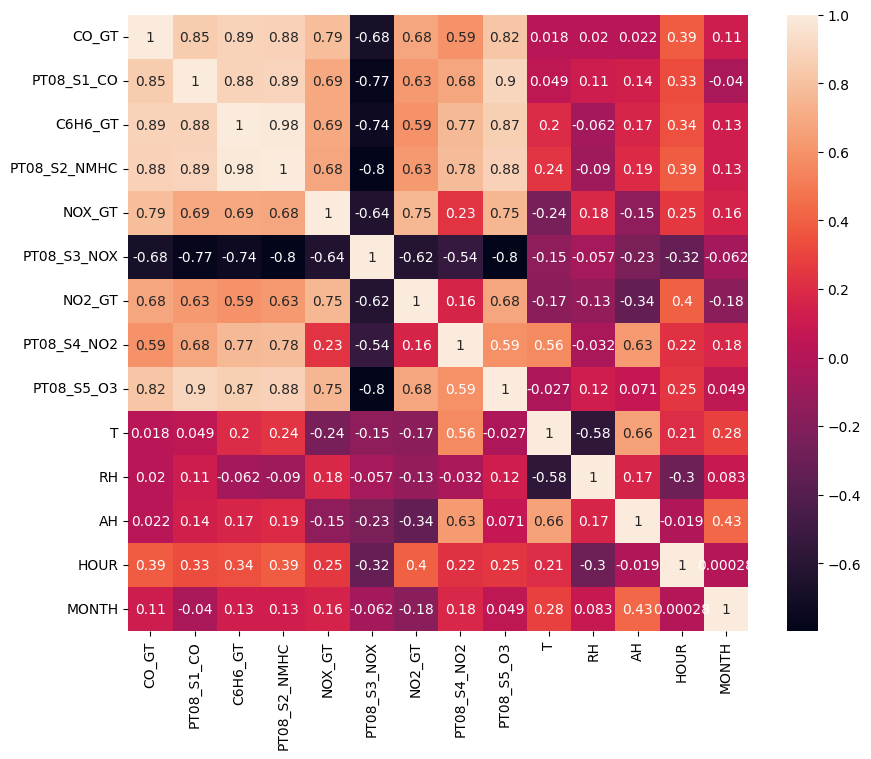

In [23]:
# Plot the heatmap
# Solution:
sns.heatmap(df_air.corr(), annot=True)
plt.show()

 - Describe the heatmap using your own words (1 point)

ANSWER: 

The figure shows the correlation coefficients in between the variables. The comment may cover these points:
1) The matrix is symmetrical because the order doesn't change the correlation calculation.
2) The values are in the range from -1 to +1. The +1 represents the strongest correlation, whereas, the -1 means also strong correlation but in inverse manner.
3) All the diagonal entries equals to +1 since correlation between the same variables equals to variance of them.
4) The values close to 0 represents uncorrelated relationship for the variables.
5) Negative correlation implies when one variable increases as the other decreases. 
6) For the linear classifiers, the correlation coefficients are related to the weights of the model.
7) The absolute value in the matrix shows how strong the relationship is between the variables.
8) The correlation coefficient measures how similar the variables vary.
9) The block of the first 9 variables have high correlation between each other

#### 5) Try to understand degree of linearity between RH output and other input features<a name="lin"></a>
 - plot all X-features against output variable RH using `sns.lmplot` (use a for-loop) (2 points)

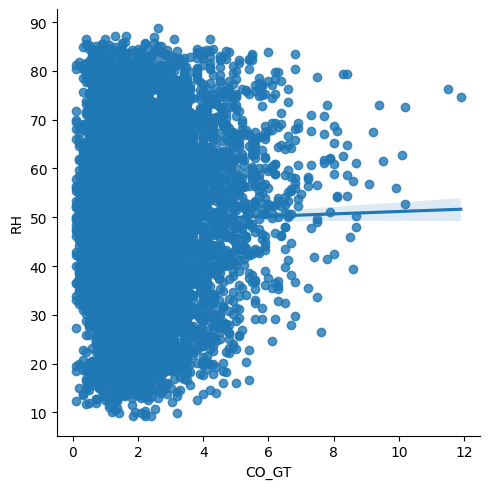

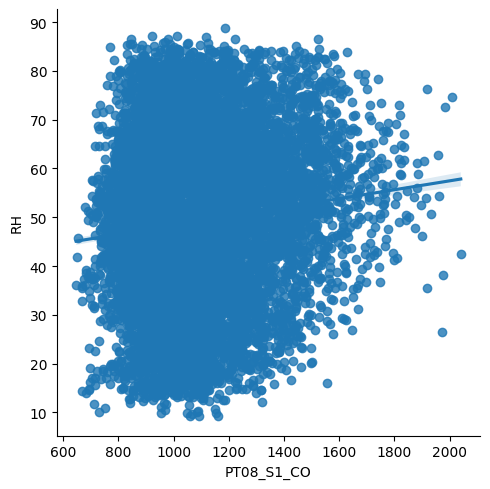

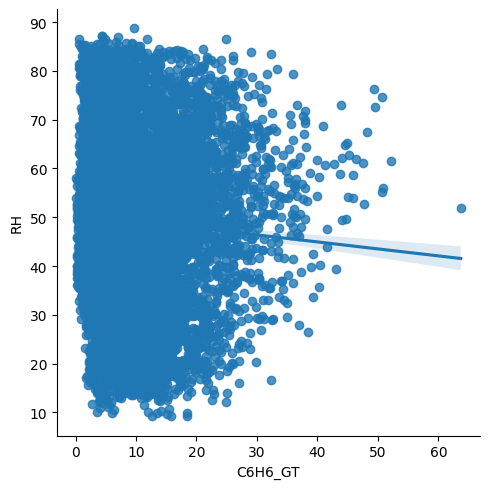

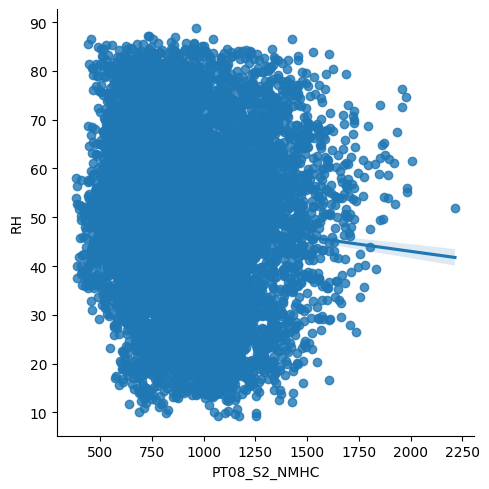

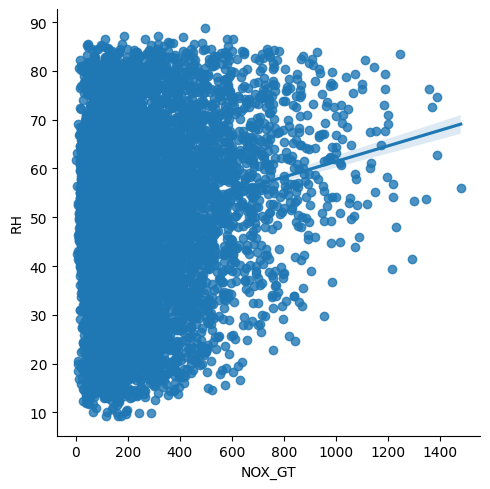

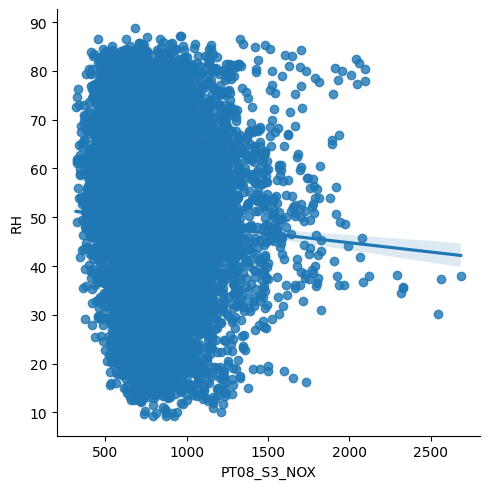

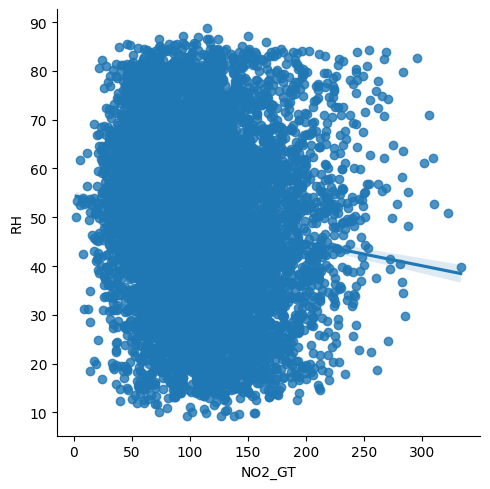

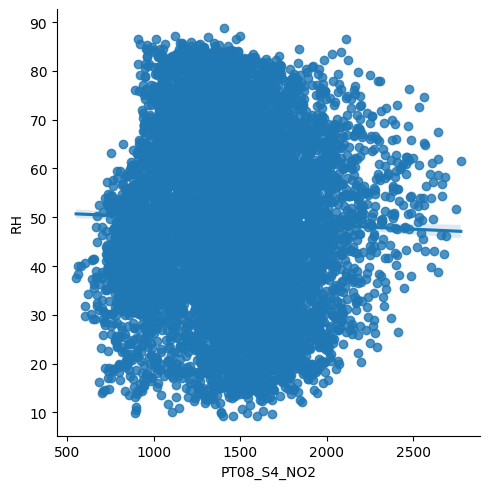

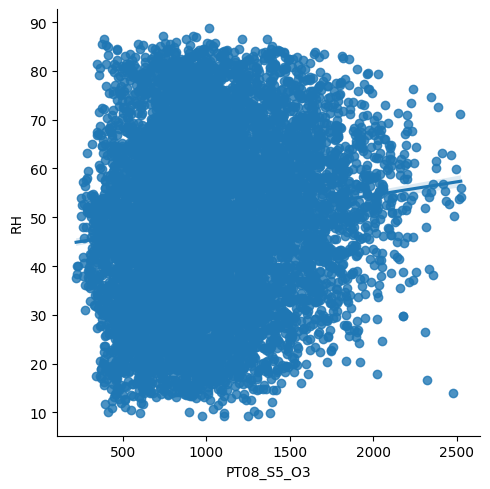

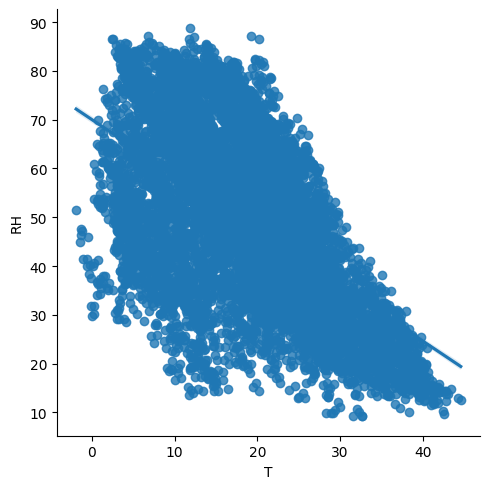

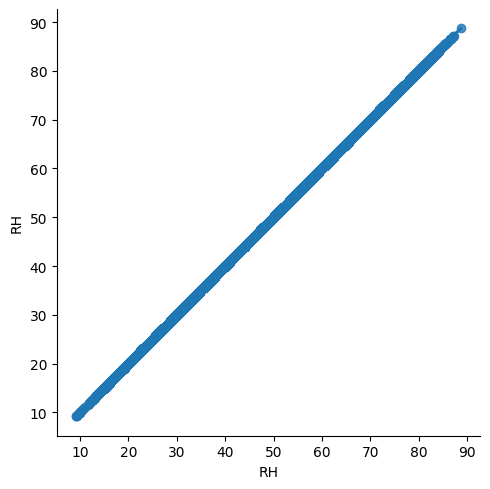

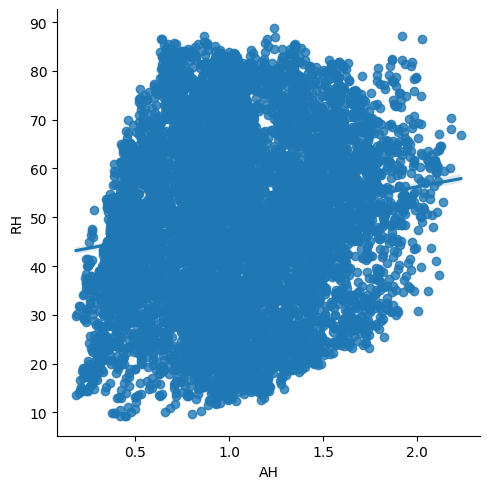

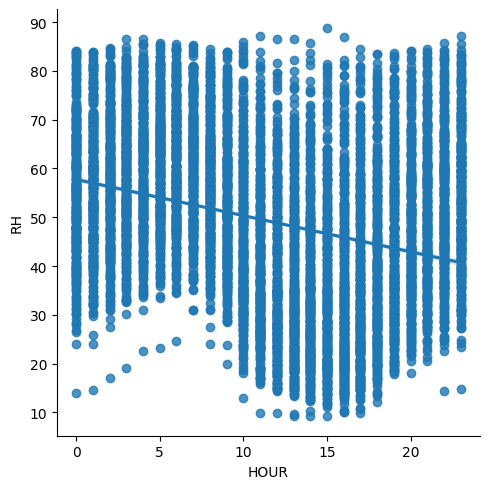

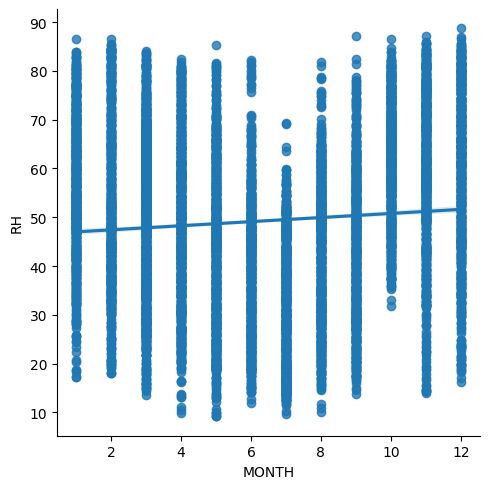

In [24]:
# Solution:
# plot all X-features against output variable RH (skip the date keys)
# NOTE: the first two columns cannot be plotted because of their data types
# So, we need to see 14 plots in total.
for column_name in df_air.keys()[2:]:
    sns.lmplot(x=column_name, y='RH', data=df_air)
    
plt.show()

- describe the results (1 point)

ANSWER: 

The comment may point out:
1) The slope of the plots are similar to the correlation coefficient in the heatplot.
2) The spreads of the plots in y-axis shows the variance of each variables.

### 6) Linear Regression<a name="LR"></a>

In [25]:
from sklearn.preprocessing import StandardScaler         #import normalisation package
from sklearn.model_selection import train_test_split      #import train test split
from sklearn.linear_model import LinearRegression         #import linear regression package
from sklearn.metrics import mean_squared_error,mean_absolute_error   #import mean squared error and mean absolute error

- Define Feature (X) and Target (y) (0.5 points)

NOTE: Check the objective of the 1st lab.

In [47]:
columns = list(df_air)
columns[12], columns[-1] = columns[-1], columns[12]
df_air.columns = columns
df_air.iloc[:, 2:]

,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOX_GT,PT08_S3_NOX,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,MONTH,AH,HOUR,RH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,3
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,3
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,3
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,3
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,10,4
8987,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,11,4
8988,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,12,4
8989,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,13,4


In [49]:
df_air

,DATE,TIME,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOX_GT,PT08_S3_NOX,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,MONTH,AH,HOUR,RH
0,2004-03-10,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,3
1,2004-03-10,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,3
2,2004-03-10,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,3
3,2004-03-10,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,3
4,2004-03-10,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986,2005-04-04,10:00:00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,10,4
8987,2005-04-04,11:00:00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,11,4
8988,2005-04-04,12:00:00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,12,4
8989,2005-04-04,13:00:00,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,13,4


In [50]:
# your code
X = df_air.iloc[:, 2:-1]  # The features (input variables)
y = df_air['RH']  # The targets

print('Shape of X: {}'.format(X.shape))
print('Shape of y: {}'.format(y.shape))

Shape of X: (8991, 13)
Shape of y: (8991,)


- Plot distribution of target variable. (0.5 points)

<AxesSubplot: ylabel='Frequency'>

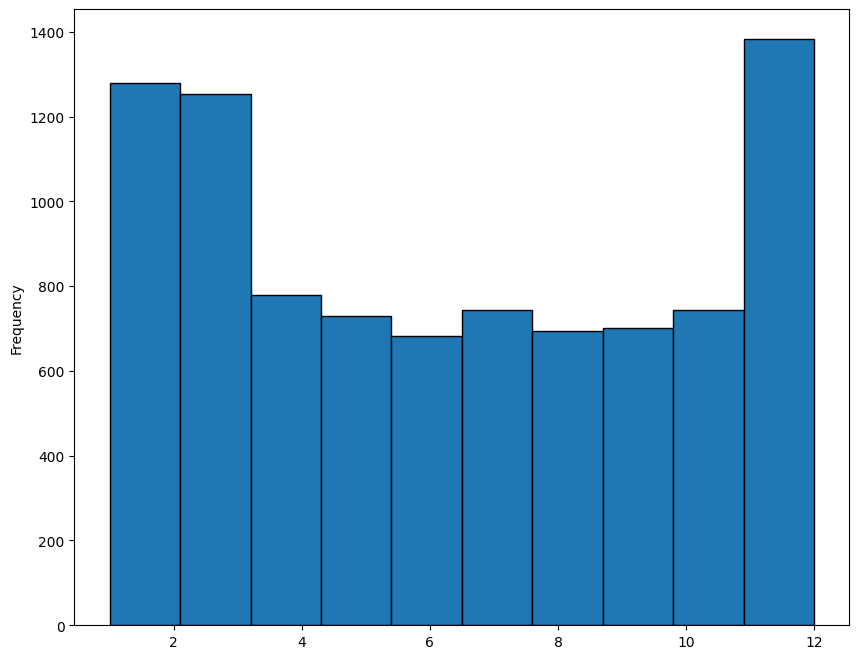

In [56]:
# your code
y.plot(kind='hist', edgecolor='black')

- Split the data into train and test with test size and 30% and train size as 70%, use a random seed.
- Print the number of train and test samples. (0.5 points)

In [57]:
from sklearn.model_selection import train_test_split

In [61]:
# your code
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Number of train samples: x_train = {} and y_train = {}'.format(x_train.shape, y_train.shape))
print('Number of test samples: x_test = {} and y_test ={}'.format(x_test.shape, y_test.shape))

Number of train samples: x_train = (6293, 13) and y_train = (6293,)
Number of test samples: x_test = (2698, 13) and y_test =(2698,)


- Normalize data using `StandardScaler` (0.5 points)

IMPORTANT: 
- Be careful about which data you are allowed to use for normalization.
- **DO NOT** forget to use the normalization for the different models (SVR etc.) !!

In [62]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

 - Train the Linear Regression model (0.5 points)
 
 See: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [65]:
from sklearn.linear_model import LinearRegression as LR 
# fitting
model = LR().fit(x_train, y_train)


In [69]:
# test
model.score(x_test, y_test)

0.5383925123419421

- Print intercept and slope of the linear model (0.5 points)

NOTE: There are more than one slopes, print them in a for loop with the corresponding variable name.

In [70]:
print(f"Slope = {model.coef_}")
print(f"Intercept = {model.intercept_}")

Slope = [ 1.21099968 -2.53795751 -2.05489848  6.43821286  1.13666207  1.4538264
 -1.60279873 -3.48924596  0.78464919  1.47089134  0.99120801  1.89725633
  0.01278616]
Intercept = 6.324646432544099


- Predict on the test data (0.5 points)
- Compute and print performance metrics as RMSE. 

This will be our baseline.

In [72]:
# Predict on the test data
y_pred = model.predict(x_test)
y_pred

array([4.52366811, 4.80355552, 9.58122213, ..., 9.92858292, 6.74661024,
       4.91847311])

In [74]:
from sklearn.metrics import mean_squared_error

print('The baseline RMSE score: ')
rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse

The baseline RMSE score: 


2.326042744712354

- Write a conclusion about the linear regression model. (0.5 points)

ANSWER: ...

### 7) Feature engineering and testing model:<a name="FE"></a>

Try with multiple feature combination and see if RMSE is improving

- Write function to measure RMSE with different combinations of features (1 point)

NOTE: Check the comments of the function.

In [84]:
def train_test_RMSE(df_air, feat_):    
    """
    The function train_test_RMSE returns the RMSE for different combinations 
    of features feat_ of the dataframe df_air.
    
        :param df_air: (pandas.DataFrame) Our dataset
        :param feat_: (List[str]) A list of column names
        :return: (float) The RMSE score value
    """
    # select features
    X = df_air.iloc[:, 2:-1]  # The features (input variables)
    y = df_air['RH']  # The targets

    X = X[feat_]

    # preprocessing
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    sc = StandardScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)

    # train model
    model = LR().fit(x_train, y_train)
    y_pred = model.predict(x_test)
    rmse = mean_squared_error(y_pred, y_test, squared=False)
    return rmse

- Train 3 models with different combination of inputs. (0.5 points)
- Try to find the 6 variable combination that gives the best score.

In [85]:
# Trail 1
feature_list = ['CO_GT', 'PT08_S1_CO', 'C6H6_GT', 'PT08_S2_NMHC']
train_test_RMSE(df_air, feature_list)

3.1884566162502828

In [86]:
# Trail 2
feature_list = ['CO_GT', 'PT08_S1_CO', 'C6H6_GT', 'NOX_GT']
train_test_RMSE(df_air, feature_list)

3.1688927087093166

In [87]:
# Trail 3
feature_list = ['CO_GT', 'PT08_S1_CO', 'C6H6_GT', 'PT08_S3_NOX']
train_test_RMSE(df_air, feature_list)

3.1907696929960045

In [ ]:
# Find the best combinations of 6 variables

- Comment on the results (0.5 points)

Hint: Is there a relationship between the score and the heatmap in the previous lab? If so, why?

ANSWER: ...

### 8) Decision Tree Regression<a name="DT"></a>

Let us try to apply Decision tree regression technique and see if any improvement happens

In [22]:
from sklearn.tree import DecisionTreeRegressor         # Decision tree regression model
from sklearn.model_selection import cross_val_score    # Import cross validation score package
from sklearn.model_selection import GridSearchCV       # Import grid search cv

- Fit the DT model and predict. (0.5 points)
- Print the score of the model.

In [ ]:
# your code
print('DT Score:')
# your code

- Write the comment on the results. Compare with the previous ones. (0.5 points)

ANSWER: ...

### 9) Random Forest Regression<a name="RF"></a>

- apply Random Forest regression and measure RMSE

In [23]:
from sklearn.ensemble import RandomForestRegressor

- Fit the RF model and predict (0.25 points)
- print the score

In [ ]:
# your code
print('RF Score:')
# your code

- Try to improve on baseline RF model: use `GridSearchCV` (0.5 points)

To search between different hyperparameters and plot the resulting RMSE:
- use different numbers of estimators
- use cv of 5 or 10
- use the correct scoring function
- then, use the best model hyperparameters to predict on the test data

In [ ]:
# your code

- Write here your conclusions regarding the Grid Search method. Did the performance improve? How much? (0.25 points)

ANSWER: ...

- ### Plot box plots of the error <a name="bxplot"></a>
    - Plot the box plots of absolute errors vs different output range. (1 point)
        - You can choose 3 intervals.
        - Then, you need to calculate the errors for each sample in the intervals.
        - Use `sns.boxplot` to plot the errors.  

In [ ]:
# your code
plt.show()

- How are the error distributed over different ranges of RH? (Uniformly/Biased/??) (1 point)

ANSWER: ...

### 10) Support Vector Machine<a name="SVM"></a>

In [24]:
from sklearn.svm import SVR           # Import support vector regressor

- Apply SVR and measure RMSE with the `linear` kernel. (0.5 points)

In [ ]:
# your code
print('SVM Score:')
# your code

- Train the model with `rbf` kernel (0.5 points)

In [ ]:
# your code
print('SVM Score:')
# your code

- Comment on the results (1 point)
- You also need to compare with the other methods.
    - What is the common property / properties in the set of models you use in this exercise?
    - Why is the one (and which one?) better than the others?
    - How could we improve the results?

ANSWER: ...


# Feedback to TAs for the first two lab sessions: (optional)

- How hard were the exercise?

ANSWER: ...

- Do the TAs fulfill your questions?

ANSWER: ...

- Do you suggest anything to add these exercises?

ANSWER: ...